In [2]:
%pip install pandas matplotlib seaborn scikit-learn numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [4]:
file_path = 'Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)

In [5]:
print(df.head())

   gender  SeniorCitizen  Dependents  tenure  PhoneService  MultipleLines  \
0       0              0           0       1             0              0   
1       1              0           0      34             1              0   
2       1              0           0       2             1              0   
3       1              0           0      45             0              0   
4       0              0           0       2             1              0   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  ...  \
0               0             1                 0            0  ...   
1               1             0                 1            0  ...   
2               1             1                 0            0  ...   
3               1             0                 1            1  ...   
4               0             0                 0            0  ...   

   MonthlyCharges  TotalCharges  Churn  Internetservice_DSL  \
0           29.85         29.85      0         

In [6]:
header = df.columns
print(header)

Index(['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService',
       'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'Internetservice_DSL',
       'Internetservice_FiberOptics', 'Internetservice_No',
       'Payment_Automatic', 'Payment_Echeck', 'Payment_Mcheck', 'Contract'],
      dtype='object')


In [7]:
import pandas as pd
import numpy as np

# --- 1. Binning Tenure ---
bins = [0, 12, 48, 72]
labels = ['New_Customer', 'Established_Customer', 'Loyal_Customer']
df['Tenure_Group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

# --- 2. Create Risk Flag ---
condition = (df['Internetservice_No'] == 0) & (df['OnlineSecurity'] == 0) & (df['TechSupport'] == 0)
df['No_Protection_Flag'] = np.where(condition, 1, 0)

# --- 3. One-Hot Encode the new Tenure_Group ---
# And drop the original column to avoid redundancy
df = pd.get_dummies(df, columns=['Tenure_Group'], drop_first=True)

# Now, let's look at the new columns
print("New engineered features added:")
print(df[['No_Protection_Flag', 'Tenure_Group_Established_Customer', 'Tenure_Group_Loyal_Customer']].head())

New engineered features added:
   No_Protection_Flag  Tenure_Group_Established_Customer  \
0                   1                              False   
1                   0                               True   
2                   0                              False   
3                   0                               True   
4                   1                              False   

   Tenure_Group_Loyal_Customer  
0                        False  
1                        False  
2                        False  
3                        False  
4                        False  


In [8]:
header = df.columns
print(header)

Index(['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService',
       'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'Internetservice_DSL',
       'Internetservice_FiberOptics', 'Internetservice_No',
       'Payment_Automatic', 'Payment_Echeck', 'Payment_Mcheck', 'Contract',
       'No_Protection_Flag', 'Tenure_Group_Established_Customer',
       'Tenure_Group_Loyal_Customer'],
      dtype='object')


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             7043 non-null   int64  
 1   SeniorCitizen                      7043 non-null   int64  
 2   Dependents                         7043 non-null   int64  
 3   tenure                             7043 non-null   int64  
 4   PhoneService                       7043 non-null   int64  
 5   MultipleLines                      7043 non-null   int64  
 6   OnlineSecurity                     7043 non-null   int64  
 7   OnlineBackup                       7043 non-null   int64  
 8   DeviceProtection                   7043 non-null   int64  
 9   TechSupport                        7043 non-null   int64  
 10  StreamingTV                        7043 non-null   int64  
 11  StreamingMovies                    7043 non-null   int64

In [10]:
# target variable
Y = df['Churn']
# features
X = df.drop('Churn', axis=1)

In [11]:
# split the data into training and testing sets
# test size = 0.2
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [12]:
# shape of train test data set
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(5634, 25) (1409, 25) (5634,) (1409,)


In [13]:
nemerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[nemerical_cols] = scaler.fit_transform(X_train[nemerical_cols])
X_test[nemerical_cols] = scaler.fit_transform(X_test[nemerical_cols])

Optimized Personal model:

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model = LogisticRegression(random_state=42,class_weight={0:1,1:1.9},C=0.01,max_iter=100, solver='liblinear')
model.fit(X_train, Y_train)
# Y_pred = model.predict(X_test)
Y_pred = model.predict_proba(X_test)[:,1] >= 0.52

# class_weight={0:1,1:1.5}
cnf_matrix = confusion_matrix(Y_test, Y_pred)
print('Confusioin Matrix:')
print(cnf_matrix)

class_report = classification_report(Y_test, Y_pred)
print('\nClassification Report:')
print(class_report)

acc_score = accuracy_score(Y_test, Y_pred)
print('\nAccuracy Score:')
print(acc_score)

Confusioin Matrix:
[[857 179]
 [101 272]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1036
           1       0.60      0.73      0.66       373

    accuracy                           0.80      1409
   macro avg       0.75      0.78      0.76      1409
weighted avg       0.82      0.80      0.81      1409


Accuracy Score:
0.801277501774308


In [25]:
# feature analysis 
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.coef_[0]})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print('\nFeature Importance:')
print(feature_importance)


Feature Importance:
                              Feature  Importance
13                     MonthlyCharges    0.391267
22                 No_Protection_Flag    0.352675
16        Internetservice_FiberOptics    0.277529
12                   PaperlessBilling    0.241055
19                     Payment_Echeck    0.195771
11                    StreamingMovies    0.165887
1                       SeniorCitizen    0.141860
5                       MultipleLines    0.113246
10                        StreamingTV    0.105293
24        Tenure_Group_Loyal_Customer    0.022114
0                              gender   -0.045097
8                    DeviceProtection   -0.046877
14                       TotalCharges   -0.099309
9                         TechSupport   -0.120581
2                          Dependents   -0.137980
15                Internetservice_DSL   -0.142533
20                     Payment_Mcheck   -0.152009
7                        OnlineBackup   -0.152861
18                  Payment_A

Grid Search Model

In [30]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2'],
    'max_iter': [100, 200, 300],
    'class_weight': ['balanced']
}

model = LogisticRegression(random_state=42)
grid_search = GridSearchCV(estimator=model, param_grid=param_grid,cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

grid_search.fit(X_train,Y_train)

print("\nBest Parameters found:", grid_search.best_params_)

# Print the best score (accuracy) achieved during the cross-validation
print("Best cross-validation accuracy:", grid_search.best_score_)


# --- Part 4: Evaluate the Best Model on the Test Set ---
print("\n--- Evaluating the Best Model Found by Grid Search ---")
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\nClassification Report on Test Set:")
print(classification_report(Y_test, y_pred_best))





Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best Parameters found: {'C': 0.001, 'class_weight': 'balanced', 'max_iter': 100, 'penalty': 'l2', 'solver': 'saga'}
Best cross-validation accuracy: 0.746362732288838

--- Evaluating the Best Model Found by Grid Search ---

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.92      0.73      0.82      1036
           1       0.52      0.82      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409



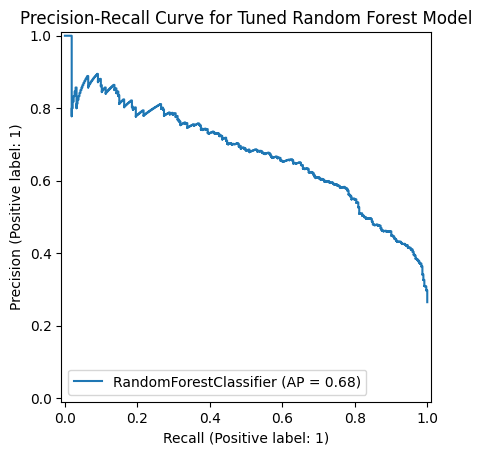

In [31]:
from sklearn.metrics import PrecisionRecallDisplay

import matplotlib.pyplot as plt

# Plot precision-recall curve for the best random forest model
PrecisionRecallDisplay.from_estimator(best_rf_model, X_test, Y_test)
plt.title('Precision-Recall Curve for Tuned Random Forest Model')
plt.show()

In [21]:
# feature analysis 
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': best_model.coef_[0]})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print('\nFeature Importance:')
print(feature_importance)


Feature Importance:
                              Feature  Importance
13                     MonthlyCharges    0.239261
22                 No_Protection_Flag    0.214182
16        Internetservice_FiberOptics    0.178304
19                     Payment_Echeck    0.154214
12                   PaperlessBilling    0.122947
1                       SeniorCitizen    0.070473
11                    StreamingMovies    0.065258
10                        StreamingTV    0.054880
5                       MultipleLines    0.040689
0                              gender   -0.008213
8                    DeviceProtection   -0.018605
4                        PhoneService   -0.024409
7                        OnlineBackup   -0.039726
24        Tenure_Group_Loyal_Customer   -0.050328
15                Internetservice_DSL   -0.059690
20                     Payment_Mcheck   -0.059759
9                         TechSupport   -0.072488
23  Tenure_Group_Established_Customer   -0.078240
2                          De

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define the parameter distribution for Random Forest (using RandomizedSearchCV to reduce computation time)
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Perform Randomized Search with f1 score to balance recall and precision (tradeoff with accuracy)
random_search_rf = RandomizedSearchCV(estimator=rf_model, param_distributions=param_dist_rf, n_iter=50, cv=5, scoring='recall', n_jobs=-1, verbose=2, random_state=42)

# Fit the randomized search to the training data
random_search_rf.fit(X_train, Y_train)

# Print the best parameters and best score
print("Best Parameters found for Random Forest:", random_search_rf.best_params_)
print("Best cross-validation f1-score:", random_search_rf.best_score_)

# Create the final model with the best parameters
best_rf_model = RandomForestClassifier(**random_search_rf.best_params_, random_state=42)
best_rf_model.fit(X_train, Y_train)

# Make predictions on the test set
y_pred_rf = best_rf_model.predict(X_test)

# Confusion Matrix
cnf_matrix_rf = confusion_matrix(Y_test, y_pred_rf)
print('Confusion Matrix for Random Forest:')
print(cnf_matrix_rf)

# Classification Report
class_report_rf = classification_report(Y_test, y_pred_rf)
print('\nClassification Report for Random Forest:')
print(class_report_rf)

# Accuracy Score
acc_score_rf = accuracy_score(Y_test, y_pred_rf)
print('\nAccuracy Score for Random Forest:')
print(acc_score_rf)

# Feature Importance
feature_importance_rf = pd.DataFrame({'Feature': X.columns, 'Importance': best_rf_model.feature_importances_})
feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)
print('\nFeature Importance for Random Forest:')
print(feature_importance_rf)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters found for Random Forest: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10, 'bootstrap': True}
Best cross-validation f1-score: 0.5153645484949833
Confusion Matrix for Random Forest:
[[956  80]
 [192 181]]

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.92      0.88      1036
           1       0.69      0.49      0.57       373

    accuracy                           0.81      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409


Accuracy Score for Random Forest:
0.8069552874378992

Feature Importance for Random Forest:
                              Feature  Importance
3                              tenure    0.175134
14                       TotalCharges    0.125784
13                     MonthlyCharges    0.122443
21                  

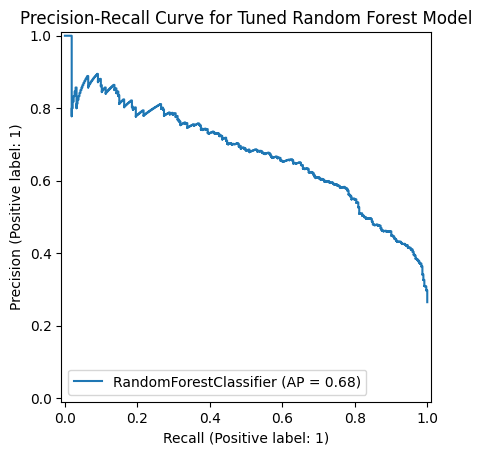

In [29]:
from sklearn.metrics import PrecisionRecallDisplay

import matplotlib.pyplot as plt

# Plot precision-recall curve for the best random forest model
PrecisionRecallDisplay.from_estimator(best_rf_model, X_test, Y_test)
plt.title('Precision-Recall Curve for Tuned Random Forest Model')
plt.show()